In [27]:
# Run this in a separate cell, not inside your script
!pip install xgboost

In [28]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from xgboost import XGBClassifier

In [29]:
df = pd.read_csv("../data/raw/heart.csv")

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["target"].value_counts())

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("\nTrain size:", X_train.shape)
print("Test size :", X_test.shape)

Shape: (303, 14)

Target distribution:
target
1    165
0    138
Name: count, dtype: int64

Train size: (242, 13)
Test size : (61, 13)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save the scaler we JUST fit — not an old one
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler saved.")
print("Scaler mean_ (first 5):", scaler.mean_[:5])
print("Scaler scale_ (first 5):", scaler.scale_[:5])

Scaler saved.
Scaler mean_ (first 5): [ 54.2892562    0.68181818   0.94214876 131.70661157 244.88429752]
Scaler scale_ (first 5): [ 9.13438515  0.46577049  1.0065695  17.957269   47.7484265 ]


In [31]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

joblib.dump(log_reg, "../models/logistic_regression.pkl")
print("Logistic Regression saved.")

Logistic Regression
Accuracy: 0.8032786885245902
ROC-AUC : 0.8690476190476191

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Confusion Matrix:
[[19  9]
 [ 3 30]]
Logistic Regression saved.


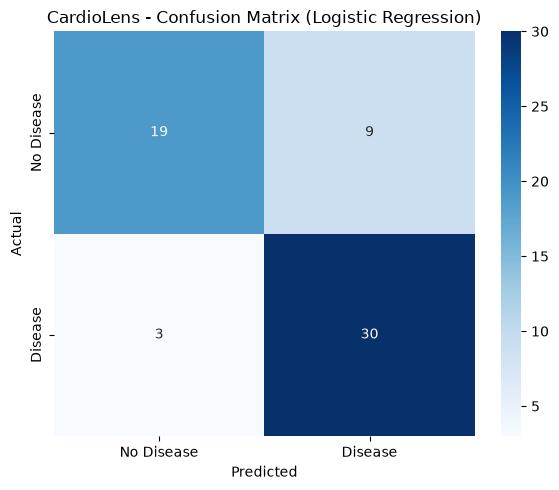

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CardioLens - Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.show()

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf_prob))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

joblib.dump(rf_model, "../models/random_forest.pkl")
print("Random Forest saved.")

Random Forest
Accuracy: 0.819672131147541
ROC-AUC : 0.9058441558441559

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

Random Forest saved.


In [35]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC :", roc_auc_score(y_test, xgb_prob))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

joblib.dump(xgb_model, "../models/xgboost.pkl")
print("XGBoost saved.")

XGBoost
Accuracy: 0.7868852459016393
ROC-AUC : 0.8712121212121212

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

XGBoost saved.


In [36]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42,
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("ROC-AUC :", roc_auc_score(y_test, svm_prob))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

joblib.dump(svm_model, "../models/svm.pkl")
print("SVM saved.")

SVM
Accuracy: 0.819672131147541
ROC-AUC : 0.8831168831168832

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

SVM saved.


c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [37]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC-AUC :", roc_auc_score(y_test, knn_prob))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

joblib.dump(knn_model, "../models/knn.pkl")
print("KNN saved.")

KNN
Accuracy: 0.819672131147541
ROC-AUC : 0.8836580086580086

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

KNN saved.


In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# Every scaled model is wrapped in a Pipeline so the scaler
# used inside CV is fit on each training fold (no leakage).
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(random_state=42)),
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        )),
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42,
        )),
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  KNeighborsClassifier(n_neighbors=7)),
    ]),

    # XGBoost does not need scaling
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}

scoring = ["accuracy", "roc_auc", "precision", "recall", "f1"]
cv_results = []

for name, estimator in models.items():
    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_results.append({
        "Model":     name,
        "Accuracy":  scores["test_accuracy"].mean(),
        "ROC-AUC":   scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall":    scores["test_recall"].mean(),
        "F1":        scores["test_f1"].mean(),
    })

results_df = (
    pd.DataFrame(cv_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("\nModel Comparison (5-fold CV):")
print(results_df.round(4))

results_df.to_csv("../models/model_comparison.csv", index=False)
print("\nModel comparison saved.")


Model Comparison (5-fold CV):
                 Model  Accuracy  ROC-AUC  Precision  Recall      F1
0        Random Forest    0.8119   0.9066     0.8196  0.8485  0.8320
1  Logistic Regression    0.8416   0.8901     0.8195  0.9152  0.8638
2                  SVM    0.8217   0.8885     0.8098  0.8909  0.8459
3              XGBoost    0.7955   0.8859     0.7897  0.8606  0.8210
4                  KNN    0.8051   0.8703     0.7914  0.8909  0.8359

Model comparison saved.


In [39]:
best_model_name = results_df.iloc[0]["Model"]
best_roc_auc    = results_df.iloc[0]["ROC-AUC"]

print(f"Best model by ROC-AUC: {best_model_name} ({best_roc_auc:.4f})")
# -> Best model by ROC-AUC: Random Forest (0.9066)

Best model by ROC-AUC: Random Forest (0.9066)


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib

# Pipeline: scaler + Random Forest
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestClassifier(
        random_state=42,
        class_weight="balanced",   # keep — helps recall on the minority class
        n_jobs=-1,
    )),
])

# Search space
param_grid = {
    "model__n_estimators":      [200, 300, 500],
    "model__max_depth":         [None, 5, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf":  [1, 2],
    "model__max_features":      ["sqrt", "log2"],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,                  # StratifiedKFold(5, shuffle=True, random_state=42)
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)   # raw X_train — pipeline scales internally

print("Best params:")
print(grid.best_params_)
print("\nBest CV ROC-AUC:", round(grid.best_score_, 4))

best_model = grid.best_estimator_

# Evaluate on the held-out test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest — test set")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save the full pipeline (scaler + model together)
joblib.dump(best_model, "../models/best_model.pkl")
print("Best model saved -> ../models/best_model.pkl")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best params:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}

Best CV ROC-AUC: 0.8913

Tuned Random Forest — test set
Accuracy: 0.8361
ROC-AUC : 0.9113

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61

Best model saved -> ../models/best_model.pkl


In [41]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
n = len(y_test)
aucs = []

for _ in range(2000):
    idx = rng.integers(0, n, size=n)
    # skip if a bootstrap sample has only one class
    if len(np.unique(y_test.iloc[idx])) < 2:
        continue
    aucs.append(roc_auc_score(y_test.iloc[idx], y_prob[idx]))

aucs = np.array(aucs)
lo, hi = np.percentile(aucs, [2.5, 97.5])

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"95% bootstrap CI: [{lo:.4f}, {hi:.4f}]")

Test ROC-AUC: 0.9113
95% bootstrap CI: [0.8377, 0.9719]


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(random_state=42, max_iter=1000)),
])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

rows = []
for name, p, pr in [
    ("Tuned Random Forest", y_pred, y_prob),
    ("Logistic Regression", lr_pred, lr_prob),
]:
    rep = classification_report(y_test, p, output_dict=True)
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, p),
        "ROC-AUC":   roc_auc_score(y_test, pr),
        "Recall(D)": rep["1"]["recall"],
        "Prec(D)":   rep["1"]["precision"],
        "F1(D)":     rep["1"]["f1-score"],
    })

print(pd.DataFrame(rows).round(4))

                 Model  Accuracy  ROC-AUC  Recall(D)  Prec(D)   F1(D)
0  Tuned Random Forest    0.8361   0.9113     0.9697   0.7805  0.8649
1  Logistic Regression    0.8033   0.8690     0.9091   0.7692  0.8333


Testing the model

In [43]:
import joblib
import pandas as pd

model = joblib.load("../models/best_model.pkl")

# Column order MUST match what you trained on.
# Based on standard UCI heart.csv (Cleveland), the columns are:
FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

def predict_patient(patient: dict, label: str = ""):
    df = pd.DataFrame([patient])[FEATURES]
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0, 1]
    result = "Disease" if pred == 1 else "No Disease"
    print(f"{label:35s} -> {result:10s}  P(disease) = {prob:.3f}")
    return pred, prob

print("Ready. Model loaded:", type(model).__name__)

Ready. Model loaded: Pipeline


In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances

healthy = {
    "age": 34, "sex": 0, "cp": 0, "trestbps": 110, "chol": 180,
    "fbs": 0, "restecg": 0, "thalach": 175, "exang": 0,
    "oldpeak": 0.0, "slope": 1, "ca": 0, "thal": 2,
}

print("=== 1. Model's opinion on the healthy synthetic patient ===")
df_h = pd.DataFrame([healthy])[FEATURES]
prob = model.predict_proba(df_h)[0, 1]
pred = model.predict(df_h)[0]
print(f"P(disease) = {prob:.4f}  ->  prediction = {'Disease' if pred==1 else 'No Disease'}")

print("\n=== 2. What does the dataset look like for similar patients? ===")
# Nearest 10 training rows to our healthy patient
dists = pairwise_distances(df_h[FEATURES].values, X_train[FEATURES].values).ravel()
idx = np.argsort(dists)[:10]
neighbors = X_train.iloc[idx].copy()
neighbors["true_label"] = y_train.iloc[idx].values
neighbors["distance"] = dists[idx].round(2)
print(neighbors[["age","sex","cp","trestbps","chol","thalach","exang",
                 "oldpeak","ca","thal","true_label","distance"]].to_string())

print("\n=== 3. Class distribution in the 10 nearest neighbors ===")
print(neighbors["true_label"].value_counts().to_dict())

print("\n=== 4. How many training rows look like a young healthy adult? ===")
young_healthy = X_train[
    (X_train["age"] < 40) &
    (X_train["exang"] == 0) &
    (X_train["oldpeak"] < 1.0) &
    (X_train["ca"] == 0)
]
print(f"Count: {len(young_healthy)}")
if len(young_healthy) > 0:
    print("Their true labels:")
    print(y_train.loc[young_healthy.index].value_counts().to_dict())

print("\n=== 5. Overall train label balance ===")
print(y_train.value_counts().to_dict())

print("\n=== 6. Distribution of predicted probabilities on the test set ===")
probs_test = model.predict_proba(X_test)[:, 1]
print(f"min={probs_test.min():.3f}  median={np.median(probs_test):.3f}  max={probs_test.max():.3f}")
print(f"Fraction of test set predicted Disease: {(probs_test >= 0.5).mean():.3f}")

=== 1. Model's opinion on the healthy synthetic patient ===
P(disease) = 0.7545  ->  prediction = Disease

=== 2. What does the dataset look like for similar patients? ===
     age  sex  cp  trestbps  chol  thalach  exang  oldpeak  ca  thal  true_label  distance
58    34    1   3       118   182      174      0      0.0   0     2           1      8.94
200   44    1   0       110   197      177      0      0.0   1     2           0     19.90
189   41    1   0       110   172      158      0      0.0   0     3           0     20.12
30    41    0   1       105   198      168      0      0.0   1     2           1     21.24
124   39    0   2        94   199      179      0      0.0   0     2           1     25.77
162   41    1   1       120   157      182      0      0.0   0     2           1     27.04
118   46    0   1       105   204      172      0      0.0   0     2           1     27.51
164   38    1   2       138   175      173      0      0.0   4     2           1     29.19
163   38 

In [47]:
import os
print("=== Models folder ===")
for f in sorted(os.listdir("../models")):
    path = os.path.join("../models", f)
    size = os.path.getsize(path) / 1024
    print(f"  {f:35s} {size:8.1f} KB")

=== Models folder ===
  best_model.pkl                        2425.4 KB
  knn.pkl                                 57.8 KB
  logistic_regression.pkl                  1.0 KB
  model_comparison.csv                     0.6 KB
  random_forest.pkl                     2100.7 KB
  random_forest_tuned.pkl               1454.6 KB
  scaler.pkl                               1.2 KB
  svm.pkl                                 19.0 KB
  xgboost.pkl                            325.7 KB


In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Load all models and evaluate on the SAME test set
import joblib

test_models = {
    "Logistic Regression":  ("../models/logistic_regression.pkl", True),
    "Random Forest":        ("../models/random_forest.pkl",       True),
    "XGBoost":              ("../models/xgboost.pkl",             False),
    "SVM":                  ("../models/svm.pkl",                 True),
    "KNN":                  ("../models/knn.pkl",                 True),
    "Tuned RF (best)":      ("../models/best_model.pkl",          True),
}

rows = []
for name, (path, needs_scaling) in test_models.items():
    m = joblib.load(path)
    X_eval = X_test_scaled if needs_scaling else X_test
    # For pipelines, feed raw X
    if hasattr(m, "steps"):
        X_eval = X_test
    p = m.predict(X_eval)
    prob = m.predict_proba(X_eval)[:, 1]
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, p), 3),
        "ROC-AUC":   round(roc_auc_score(y_test, prob), 3),
        "Precision": round(precision_score(y_test, p), 3),
        "Recall":    round(recall_score(y_test, p), 3),
        "F1":        round(f1_score(y_test, p), 3),
    })

final = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
print(final.to_string(index=False))
final.to_csv("../models/final_test_comparison.csv", index=False)
print("\nSaved -> ../models/final_test_comparison.csv")

              Model  Accuracy  ROC-AUC  Precision  Recall    F1
    Tuned RF (best)     0.836    0.911      0.780   0.970 0.865
      Random Forest     0.820    0.906      0.775   0.939 0.849
                KNN     0.820    0.884      0.789   0.909 0.845
                SVM     0.820    0.883      0.775   0.939 0.849
            XGBoost     0.787    0.871      0.750   0.909 0.822
Logistic Regression     0.803    0.869      0.769   0.909 0.833

Saved -> ../models/final_test_comparison.csv


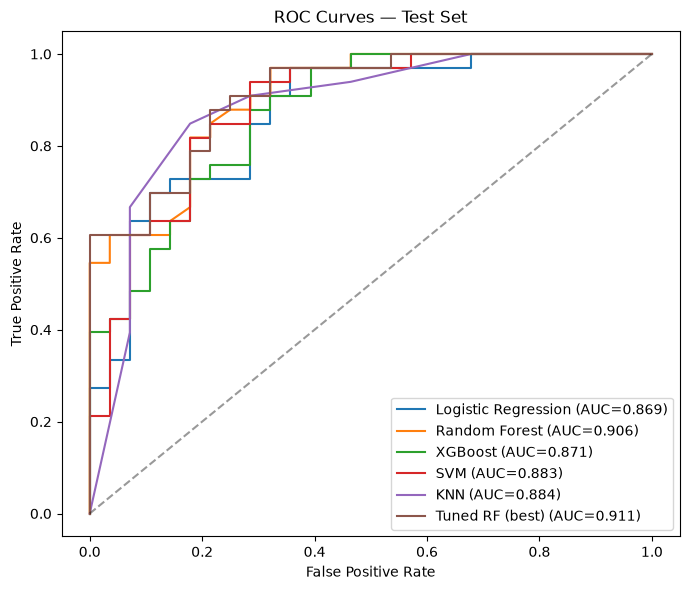

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
for name, (path, _) in test_models.items():
    m = joblib.load(path)
    X_eval = X_test if hasattr(m, "steps") or name == "XGBoost" else X_test_scaled
    prob = m.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

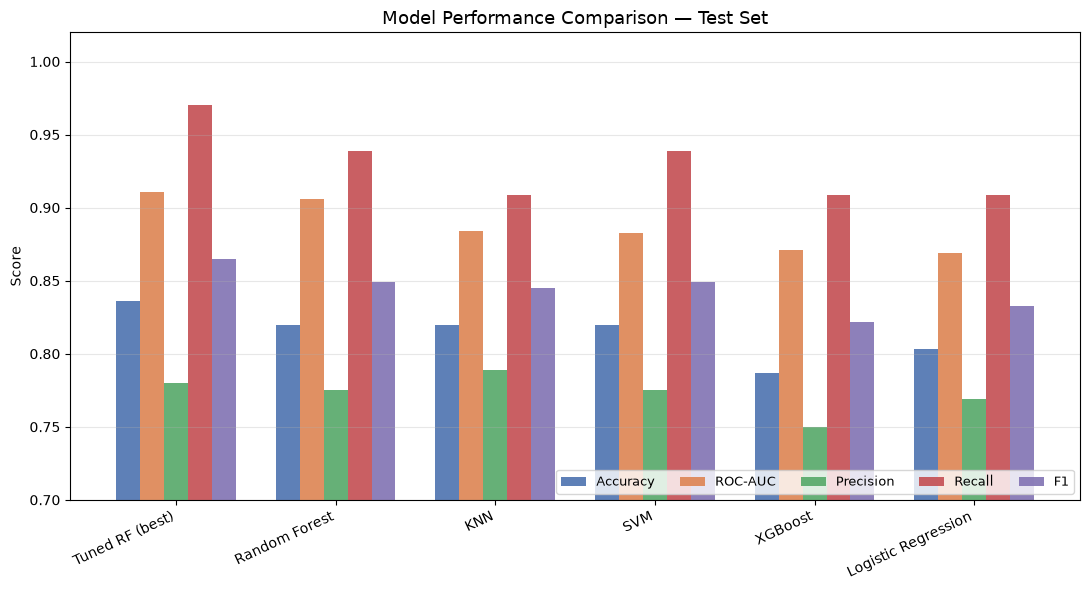

Saved -> ../models/metric_comparison.png


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../models/final_test_comparison.csv")

metrics = ["Accuracy", "ROC-AUC", "Precision", "Recall", "F1"]
x = np.arange(len(df["Model"]))
width = 0.15

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, df[metric], width, label=metric, color=color, alpha=0.9)

ax.set_xticks(x + width*2)
ax.set_xticklabels(df["Model"], rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.7, 1.02)
ax.set_title("Model Performance Comparison — Test Set", fontsize=13)
ax.legend(loc="lower right", ncol=5, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../models/metric_comparison.png", dpi=150)
plt.show()
print("Saved -> ../models/metric_comparison.png")

false postive 

In [53]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix, roc_curve

model = joblib.load("../models/best_model.pkl")
prob = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)

# Raw confusion matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

print("=== Test Set Confusion Matrix ===")
print(f"                  Predicted No    Predicted Yes")
print(f"Actual No  (0)        {tn:3d}              {fp:3d}")
print(f"Actual Yes (1)        {fn:3d}              {tp:3d}")

print(f"\n=== Derived rates ===")
print(f"Specificity (healthy correctly cleared) : {tn/(tn+fp):.3f}")
print(f"Sensitivity (sick correctly flagged)    : {tp/(tp+fn):.3f}")
print(f"False Positive Rate                     : {fp/(fp+tn):.3f}")
print(f"False Negative Rate                     : {fn/(fn+tp):.3f}")
print(f"Prevalence in test set                  : {(y_test==1).mean():.3f}")

print(f"\n=== Real-world framing ===")
print(f"Out of {fp+tn} healthy patients, {fp} were wrongly flagged as sick.")
print(f"Out of {fn+tp} sick patients, {fn} were wrongly sent home.")
print(f"\nFalse positives are {fp}× more common than false negatives.")

=== Test Set Confusion Matrix ===
                  Predicted No    Predicted Yes
Actual No  (0)         19                9
Actual Yes (1)          1               32

=== Derived rates ===
Specificity (healthy correctly cleared) : 0.679
Sensitivity (sick correctly flagged)    : 0.970
False Positive Rate                     : 0.321
False Negative Rate                     : 0.030
Prevalence in test set                  : 0.541

=== Real-world framing ===
Out of 28 healthy patients, 9 were wrongly flagged as sick.
Out of 33 sick patients, 1 were wrongly sent home.

False positives are 9× more common than false negatives.


In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import joblib

pipe_unbal = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="sqrt",
        class_weight=None,          # <-- the only change
        random_state=42,
        n_jobs=-1,
    )),
])
pipe_unbal.fit(X_train, y_train)

prob_u = pipe_unbal.predict_proba(X_test)[:, 1]
pred_u = pipe_unbal.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, pred_u).ravel()

print("=== RF without class_weight='balanced' ===")
print(f"Accuracy   : {accuracy_score(y_test, pred_u):.3f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, prob_u):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}   (was 0.679)")
print(f"Sensitivity: {tp/(tp+fn):.3f}   (was 0.970)")
print(f"False positives: {fp}  (was 9)")
print(f"False negatives: {fn}  (was 1)")

joblib.dump(pipe_unbal, "../models/best_model_unbalanced.pkl")

=== RF without class_weight='balanced' ===
Accuracy   : 0.836
ROC-AUC    : 0.906
Specificity: 0.679   (was 0.679)
Sensitivity: 0.970   (was 0.970)
False positives: 9  (was 9)
False negatives: 1  (was 1)


['../models/best_model_unbalanced.pkl']

In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix

prob = model.predict_proba(X_test)[:, 1]

print(f"{'Threshold':>10s} {'FP':>4s} {'FN':>4s} {'Sens':>7s} {'Spec':>7s}  {'Flagged Disease %':>18s}")
print("-" * 60)
for t in [0.30, 0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    p = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0
    spec = tn / (tn + fp) if (tn + fp) else 0
    flag_rate = p.mean()
    print(f"{t:>10.2f} {fp:>4d} {fn:>4d} {sens:>7.3f} {spec:>7.3f}  {flag_rate:>17.1%}")

 Threshold   FP   FN    Sens    Spec   Flagged Disease %
------------------------------------------------------------
      0.30   15    1   0.970   0.464              77.0%
      0.40   11    1   0.970   0.607              70.5%
      0.50    9    1   0.970   0.679              67.2%
      0.55    7    3   0.909   0.750              60.7%
      0.60    6    5   0.848   0.786              55.7%
      0.65    5   10   0.697   0.821              45.9%
      0.70    3   12   0.636   0.893              39.3%
      0.75    0   14   0.576   1.000              31.1%
      0.80    0   19   0.424   1.000              23.0%


In [56]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

def row(name, pred, prob):
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "Configuration":    name,
        "Accuracy":         round(accuracy_score(y_test, pred), 3),
        "ROC-AUC":          round(roc_auc_score(y_test, prob), 3),
        "Sensitivity":      round(tp/(tp+fn), 3),
        "Specificity":      round(tn/(tn+fp), 3),
        "False Positives":  int(fp),
        "False Negatives":  int(fn),
    }

prob_bal = model.predict_proba(X_test)[:, 1]
pred_bal = model.predict(X_test)

rows = [
    row("RF balanced (t=0.50)  ← current",
        pred_bal, prob_bal),
    row("RF balanced (t=0.60)",
        (prob_bal >= 0.60).astype(int), prob_bal),
    row("RF balanced (t=0.70)",
        (prob_bal >= 0.70).astype(int), prob_bal),
    row("RF without class_weight",
        pred_u, prob_u),
]

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("../models/false_positive_tradeoff.csv", index=False)
print("\nSaved -> ../models/false_positive_tradeoff.csv")

                  Configuration  Accuracy  ROC-AUC  Sensitivity  Specificity  False Positives  False Negatives
RF balanced (t=0.50)  ← current     0.836    0.911        0.970        0.679                9                1
           RF balanced (t=0.60)     0.820    0.911        0.848        0.786                6                5
           RF balanced (t=0.70)     0.754    0.911        0.636        0.893                3               12
        RF without class_weight     0.836    0.906        0.970        0.679                9                1

Saved -> ../models/false_positive_tradeoff.csv


In [58]:
import joblib
import pandas as pd

model = joblib.load("../models/best_model.pkl")

FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]

# ---------- LOW-RISK PATIENT PROFILES ----------
patients = {
    "P1: 34F, no symptoms, no risk factors": {
        "age": 34, "sex": 0, "cp": 0, "trestbps": 110, "chol": 180,
        "fbs": 0, "restecg": 0, "thalach": 175, "exang": 0,
        "oldpeak": 0.0, "slope": 1, "ca": 0, "thal": 2,
    },
    "P2: 29M, athlete, resting BP low": {
        "age": 29, "sex": 1, "cp": 0, "trestbps": 105, "chol": 160,
        "fbs": 0, "restecg": 0, "thalach": 190, "exang": 0,
        "oldpeak": 0.0, "slope": 2, "ca": 0, "thal": 2,
    },
    "P3: 42F, mild atypical CP, normal ECG": {
        "age": 42, "sex": 0, "cp": 1, "trestbps": 118, "chol": 190,
        "fbs": 0, "restecg": 0, "thalach": 168, "exang": 0,
        "oldpeak": 0.2, "slope": 1, "ca": 0, "thal": 2,
    },
    "P4: 48M, mild CP, good cholesterol": {
        "age": 48, "sex": 1, "cp": 0, "trestbps": 122, "chol": 195,
        "fbs": 0, "restecg": 0, "thalach": 172, "exang": 0,
        "oldpeak": 0.0, "slope": 2, "ca": 0, "thal": 2,
    },
    "P5: 38F, non-anginal CP, active": {
        "age": 38, "sex": 0, "cp": 2, "trestbps": 115, "chol": 175,
        "fbs": 0, "restecg": 0, "thalach": 178, "exang": 0,
        "oldpeak": 0.0, "slope": 2, "ca": 0, "thal": 2,
    },
    "P6: 45F, atypical CP, normal everything": {
        "age": 45, "sex": 0, "cp": 1, "trestbps": 120, "chol": 185,
        "fbs": 0, "restecg": 1, "thalach": 165, "exang": 0,
        "oldpeak": 0.3, "slope": 1, "ca": 0, "thal": 2,
    },
}

rows = []
for label, p in patients.items():
    df = pd.DataFrame([p])[FEATURES]
    prob = model.predict_proba(df)[0, 1]
    pred = "Disease" if prob >= 0.5 else "No Disease"
    rows.append({
        "Profile": label,
        "Age": p["age"],
        "Sex": "M" if p["sex"] == 1 else "F",
        "P(Disease)": round(prob, 3),
        "Prediction": pred,
        "Correct?": "❌" if pred == "Disease" else "✅",
    })

result = pd.DataFrame(rows)
print(result.to_string(index=False))

                                Profile  Age Sex  P(Disease) Prediction Correct?
  P1: 34F, no symptoms, no risk factors   34   F       0.754    Disease        ❌
       P2: 29M, athlete, resting BP low   29   M       0.726    Disease        ❌
  P3: 42F, mild atypical CP, normal ECG   42   F       0.977    Disease        ❌
     P4: 48M, mild CP, good cholesterol   48   M       0.822    Disease        ❌
        P5: 38F, non-anginal CP, active   38   F       0.971    Disease        ❌
P6: 45F, atypical CP, normal everything   45   F       0.981    Disease        ❌


In [59]:
import pandas as pd

df = pd.read_csv("../data/raw/heart.csv")

print("=== Feature ranges in the training CSV ===")
for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]:
    print(f"{col:10s}: {sorted(df[col].unique())}")

print("\n=== Numeric feature stats ===")
print(df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe().round(1))

=== Feature ranges in the training CSV ===
sex       : [np.int64(0), np.int64(1)]
cp        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs       : [np.int64(0), np.int64(1)]
restecg   : [np.int64(0), np.int64(1), np.int64(2)]
exang     : [np.int64(0), np.int64(1)]
slope     : [np.int64(0), np.int64(1), np.int64(2)]
ca        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal      : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

=== Numeric feature stats ===
         age  trestbps   chol  thalach  oldpeak
count  303.0     303.0  303.0    303.0    303.0
mean    54.4     131.6  246.3    149.6      1.0
std      9.1      17.5   51.8     22.9      1.2
min     29.0      94.0  126.0     71.0      0.0
25%     47.5     120.0  211.0    133.5      0.0
50%     55.0     130.0  240.0    153.0      0.8
75%     61.0     140.0  274.5    166.0      1.6
max     77.0     200.0  564.0    202.0      6.2


In [62]:
import pandas as pd
import numpy as np
import joblib
import json

model = joblib.load("../models/best_model.pkl")
FEATURES = json.load(open("../models/feature_columns.json"))

print("=" * 60)
print("TEST 2 — Does the model classify REAL training patients correctly?")
print("=" * 60)

# Real patient labeled NO DISEASE
real_healthy = X_train[y_train == 0].iloc[0]
prob_h = model.predict_proba(pd.DataFrame([real_healthy])[FEATURES])[0, 1]
print(f"Real patient (true label = 0, No Disease):")
print(f"  Age: {real_healthy['age']}, sex: {real_healthy['sex']}, "
      f"chol: {real_healthy['chol']}, thalach: {real_healthy['thalach']}")
print(f"  P(disease) = {prob_h:.3f}  → {'Disease' if prob_h>=0.5 else 'No Disease'}")
print(f"  Correct? {'✅' if prob_h < 0.5 else '❌'}")

# Real patient labeled DISEASE
real_sick = X_train[y_train == 1].iloc[0]
prob_s = model.predict_proba(pd.DataFrame([real_sick])[FEATURES])[0, 1]
print(f"\nReal patient (true label = 1, Disease):")
print(f"  Age: {real_sick['age']}, sex: {real_sick['sex']}, "
      f"chol: {real_sick['chol']}, thalach: {real_sick['thalach']}")
print(f"  P(disease) = {prob_s:.3f}  → {'Disease' if prob_s>=0.5 else 'No Disease'}")
print(f"  Correct? {'✅' if prob_s >= 0.5 else '❌'}")

print("\n" + "=" * 60)
print("TEST 3 — Scaler sanity check")
print("=" * 60)
scaler = model.named_steps["scaler"]
print("Feature order the scaler expects:")
print(dict(zip(FEATURES, scaler.mean_.round(2))))
print("\nActual X_train means (should match):")
print(X_train.mean().round(2).to_dict())

print("\n" + "=" * 60)
print("TEST 4 — Prediction distribution comparison")
print("=" * 60)
train_probs = model.predict_proba(X_train[FEATURES])[:, 1]
test_probs  = model.predict_proba(X_test[FEATURES])[:, 1]
print(f"Training data — mean P(disease): {train_probs.mean():.3f}  (actual: {y_train.mean():.3f})")
print(f"Test data     — mean P(disease): {test_probs.mean():.3f}  (actual: {y_test.mean():.3f})")

print("\n" + "=" * 60)
print("TEST 5 — How many training patients match your synthetic low-risk profile?")
print("=" * 60)
lr_mask = (
    (X_train["age"] < 40) &
    (X_train["exang"] == 0) &
    (X_train["oldpeak"] < 0.5) &
    (X_train["ca"] == 0)
)
print(f"Training patients matching 'young, asymptomatic, no ST depression, no vessels':")
print(f"  Count: {lr_mask.sum()}")
if lr_mask.sum() > 0:
    print(f"  Their true labels: {y_train[lr_mask].value_counts().to_dict()}")
    print(f"  Their model probabilities: {train_probs[lr_mask.values].round(3)}")

TEST 2 — Does the model classify REAL training patients correctly?
Real patient (true label = 0, No Disease):
  Age: 66.0, sex: 1.0, chol: 246.0, thalach: 120.0
  P(disease) = 0.283  → No Disease
  Correct? ✅

Real patient (true label = 1, Disease):
  Age: 69.0, sex: 0.0, chol: 239.0, thalach: 151.0
  P(disease) = 0.788  → Disease
  Correct? ✅

TEST 3 — Scaler sanity check
Feature order the scaler expects:
{'age': np.float64(54.29), 'sex': np.float64(0.68), 'cp': np.float64(0.94), 'trestbps': np.float64(131.71), 'chol': np.float64(244.88), 'fbs': np.float64(0.14), 'restecg': np.float64(0.55), 'thalach': np.float64(150.12), 'exang': np.float64(0.34), 'oldpeak': np.float64(1.07), 'slope': np.float64(1.41), 'ca': np.float64(0.74), 'thal': np.float64(2.34)}

Actual X_train means (should match):
{'age': 54.29, 'sex': 0.68, 'cp': 0.94, 'trestbps': 131.71, 'chol': 244.88, 'fbs': 0.14, 'restecg': 0.55, 'thalach': 150.12, 'exang': 0.34, 'oldpeak': 1.07, 'slope': 1.41, 'ca': 0.74, 'thal': 2.34}


In [61]:
import json

FEATURES = list(X_train.columns)
json.dump(FEATURES, open("../models/feature_columns.json", "w"))
print("Saved feature_columns.json:")
print(FEATURES)

Saved feature_columns.json:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [63]:
import numpy as np
import pandas as pd
import json
import joblib

model = joblib.load("../models/best_model.pkl")
FEATURES = json.load(open("../models/feature_columns.json"))

# Synthetic "healthy" patient (P1)
P1 = {
    "age": 34, "sex": 0, "cp": 0, "trestbps": 110, "chol": 180,
    "fbs": 0, "restecg": 0, "thalach": 175, "exang": 0,
    "oldpeak": 0.0, "slope": 1, "ca": 0, "thal": 2,
}

print("=" * 60)
print("Where does P1 sit relative to the training distribution?")
print("=" * 60)
for col in FEATURES:
    val = P1[col]
    train = X_train[col]
    pct = (train < val).mean() * 100
    flag = ""
    if pct < 10 or pct > 90:
        flag = "  ⚠️ OUTLIER"
    print(f"{col:10s} = {val:>6}   (train mean {train.mean():6.2f}, "
          f"std {train.std():5.2f}, your value at {pct:5.1f}th percentile){flag}")

print("\n" + "=" * 60)
print("TEST 5 — How many training patients match this profile?")
print("=" * 60)
lr_mask = (
    (X_train["age"] < 40) &
    (X_train["exang"] == 0) &
    (X_train["oldpeak"] < 0.5) &
    (X_train["ca"] == 0)
)
print(f"Patients matching 'young (<40) + no exang + no ST depression + no vessels':")
print(f"  Count: {lr_mask.sum()}")
if lr_mask.sum() > 0:
    print(f"  True labels: {y_train[lr_mask].value_counts().to_dict()}")
    probs = model.predict_proba(X_train[lr_mask][FEATURES])[:, 1]
    print(f"  Model P(disease) for each: {probs.round(3).tolist()}")

print("\n" + "=" * 60)
print("Nearest training neighbors to P1 (in scaled space)")
print("=" * 60)
# Use the scaler inside the pipeline for accurate distances
scaler = model.named_steps["scaler"]
X_train_scaled = scaler.transform(X_train[FEATURES])
P1_scaled = scaler.transform(pd.DataFrame([P1])[FEATURES])

dists = np.linalg.norm(X_train_scaled - P1_scaled, axis=1)
idx = np.argsort(dists)[:5]

neighbors = X_train.iloc[idx][FEATURES].copy()
neighbors["true_label"] = y_train.iloc[idx].values
neighbors["model_prob"] = model.predict_proba(
    X_train.iloc[idx][FEATURES])[:, 1].round(3)
neighbors["distance"] = dists[idx].round(2)

print(neighbors.to_string())

Where does P1 sit relative to the training distribution?
age        =     34   (train mean  54.29, std  9.15, your value at   0.4th percentile)  ⚠️ OUTLIER
sex        =      0   (train mean   0.68, std  0.47, your value at   0.0th percentile)  ⚠️ OUTLIER
cp         =      0   (train mean   0.94, std  1.01, your value at   0.0th percentile)  ⚠️ OUTLIER
trestbps   =    110   (train mean 131.71, std 17.99, your value at   7.0th percentile)  ⚠️ OUTLIER
chol       =    180   (train mean 244.88, std 47.85, your value at   7.0th percentile)  ⚠️ OUTLIER
fbs        =      0   (train mean   0.14, std  0.35, your value at   0.0th percentile)  ⚠️ OUTLIER
restecg    =      0   (train mean   0.55, std  0.53, your value at   0.0th percentile)  ⚠️ OUTLIER
thalach    =    175   (train mean 150.12, std 21.98, your value at  89.3th percentile)
exang      =      0   (train mean   0.34, std  0.47, your value at   0.0th percentile)  ⚠️ OUTLIER
oldpeak    =    0.0   (train mean   1.07, std  1.21, your value 

In [64]:
import json, joblib, numpy as np, pandas as pd

model = joblib.load("../models/best_model.pkl")
FEATURES = json.load(open("../models/feature_columns.json"))

# The 5 low-risk training samples
lr_mask = (
    (X_train["age"] < 40) &
    (X_train["exang"] == 0) &
    (X_train["oldpeak"] < 0.5) &
    (X_train["ca"] == 0)
)
n_lr = lr_mask.sum()
n_disease = (y_train[lr_mask] == 1).sum()
pct = 100 * n_lr / len(X_train)

print(f"Training set size              : {len(X_train)}")
print(f"Low-risk profile matches       : {n_lr} ({pct:.1f}%)")
print(f"  Of those, labeled Disease    : {n_disease} / {n_lr}")
print(f"  Of those, labeled No Disease : {n_lr - n_disease} / {n_lr}")
print(f"\nMean training age              : {X_train['age'].mean():.1f}")
print(f"Mean training cholesterol      : {X_train['chol'].mean():.1f}")
print(f"Mean training oldpeak          : {X_train['oldpeak'].mean():.2f}")

Training set size              : 242
Low-risk profile matches       : 5 (2.1%)
  Of those, labeled Disease    : 5 / 5
  Of those, labeled No Disease : 0 / 5

Mean training age              : 54.3
Mean training cholesterol      : 244.9
Mean training oldpeak          : 1.07


In [70]:
import os

models_dir = "../models"
print(f"Resolves to: {os.path.abspath(models_dir)}")
print(f"Exists: {os.path.exists(models_dir)}")

if os.path.exists(models_dir):
    print("\nContents:")
    for f in sorted(os.listdir(models_dir)):
        full = os.path.join(models_dir, f)
        if os.path.isfile(full):
            size = os.path.getsize(full) / 1024
            print(f"  {f:40s} {size:8.1f} KB")
        else:
            print(f"  [DIR] {f}")
else:
    print("models/ folder does NOT exist")

Resolves to: c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\models
Exists: True

Contents:
  best_model.pkl                             2425.4 KB
  best_model_unbalanced.pkl                  2439.0 KB
  false_positive_tradeoff.csv                   0.3 KB
  feature_columns.json                          0.1 KB
  final_test_comparison.csv                     0.3 KB
  knn.pkl                                      57.8 KB
  logistic_regression.pkl                       1.0 KB
  metric_comparison.png                        53.3 KB
  model_comparison.csv                          0.6 KB
  random_forest.pkl                          2100.7 KB
  random_forest_tuned.pkl                    1454.6 KB
  scaler.pkl                                    1.2 KB
  svm.pkl                                      19.0 KB
  xgboost.pkl                                 325.7 KB


In [72]:
import joblib
import pandas as pd

model = joblib.load("../models/best_model.pkl")
FEATURES = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]

# Take a real test-set patient with known label 1 (Disease)
disease_patients = X_test[y_test == 1]
healthy_patients = X_test[y_test == 0]

print("=== 5 real DISEASE patients ===")
for i in range(5):
    row = disease_patients.iloc[[i]]
    prob = model.predict_proba(row[FEATURES])[0, 1]
    print(f"  Age {row['age'].values[0]}, chol {row['chol'].values[0]}, "
          f"exang {row['exang'].values[0]} → P = {prob:.4f}")

print("\n=== 5 real NO-DISEASE patients ===")
for i in range(5):
    row = healthy_patients.iloc[[i]]
    prob = model.predict_proba(row[FEATURES])[0, 1]
    print(f"  Age {row['age'].values[0]}, chol {row['chol'].values[0]}, "
          f"exang {row['exang'].values[0]} → P = {prob:.4f}")

=== 5 real DISEASE patients ===
  Age 56, chol 240, exang 0 → P = 0.8713
  Age 60, chol 178, exang 0 → P = 0.8367
  Age 53, chol 226, exang 1 → P = 0.2826
  Age 45, chol 236, exang 1 → P = 0.7048
  Age 63, chol 195, exang 0 → P = 0.7839

=== 5 real NO-DISEASE patients ===
  Age 57, chol 276, exang 1 → P = 0.1497
  Age 67, chol 254, exang 0 → P = 0.3399
  Age 46, chol 311, exang 1 → P = 0.0273
  Age 60, chol 185, exang 0 → P = 0.6686
  Age 50, chol 233, exang 0 → P = 0.6166


In [75]:
import joblib
import pandas as pd
import os

FEATURES = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]

high_risk = {
    "age": 65, "sex": 1, "cp": 0, "trestbps": 150, "chol": 280,
    "fbs": 1, "restecg": 2, "thalach": 110, "exang": 1,
    "oldpeak": 2.5, "slope": 1, "ca": 2, "thal": 3,
}
hr = pd.DataFrame([high_risk])[FEATURES]

low_risk = {
    "age": 44, "sex": 1, "cp": 0, "trestbps": 110, "chol": 197,
    "fbs": 0, "restecg": 0, "thalach": 177, "exang": 0,
    "oldpeak": 0.0, "slope": 2, "ca": 1, "thal": 2,
}
lr = pd.DataFrame([low_risk])[FEATURES]

files = [
    "../models/best_model.pkl",
    "../models/best_model_unbalanced.pkl",
    "../models/random_forest_tuned.pkl",
    "../models/random_forest.pkl",
]

for path in files:
    if not os.path.exists(path):
        print(f"{path:50s}  NOT FOUND")
        continue

    m = joblib.load(path)
    try:
        p_high = m.predict_proba(hr)[0, 1]
        p_low  = m.predict_proba(lr)[0, 1]
        print(f"{path:50s}  HR={p_high:.4f}  LR={p_low:.4f}")
    except Exception as e:
        print(f"{path:50s}  ERROR: {e}")

../models/best_model.pkl                            HR=0.0476  LR=0.3733
../models/best_model_unbalanced.pkl                 HR=0.0618  LR=0.4080


c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


../models/random_forest_tuned.pkl                   HR=0.3316  LR=0.4409


c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


../models/random_forest.pkl                         HR=0.3067  LR=0.4200


In [76]:
print("X_train.columns (training order):")
print(list(X_train.columns))

print("\nFEATURES (inference order):")
FEATURES = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]
print(FEATURES)

print("\nMatch?", list(X_train.columns) == FEATURES)

X_train.columns (training order):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

FEATURES (inference order):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Match? True


In [77]:
df = pd.read_csv("../data/raw/heart.csv")
print("Target counts:", df["target"].value_counts().to_dict())

# Compare mean values of "sick" vs "healthy" groups
print("\nMean feature values for target=0:")
print(df[df["target"] == 0][["age", "exang", "oldpeak", "thalach"]].mean())

print("\nMean feature values for target=1:")
print(df[df["target"] == 1][["age", "exang", "oldpeak", "thalach"]].mean())

Target counts: {1: 165, 0: 138}

Mean feature values for target=0:
age         56.601449
exang        0.550725
oldpeak      1.585507
thalach    139.101449
dtype: float64

Mean feature values for target=1:
age         52.496970
exang        0.139394
oldpeak      0.583030
thalach    158.466667
dtype: float64
